In [2]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()  # zip'i seç buradan

with zipfile.ZipFile("lung_cancer.zip", "r") as z:
    z.extractall("dataset")

print("Klasörler:")
for f in os.listdir("dataset"):
    print(f" -", f)

Saving lung_cancer.zip to lung_cancer.zip
Klasörler:
 - Bengin cases
 - Normal cases
 - Malignant cases


In [3]:
import os

classes = {
    "Bengin cases": "Benign",
    "Normal cases": "Normal",
    "Malignant cases": "Malignant"
}

for folder, label in classes.items():
    path = f"dataset/{folder}"
    count = len(os.listdir(path))
    print(f"{label}: {count} görüntü")

Benign: 120 görüntü
Normal: 416 görüntü
Malignant: 561 görüntü


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch version: 2.10.0+cu128
GPU available: True
Device: Tesla T4


In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch
import numpy as np
import os

# Data transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Rename folders to clean names first
import shutil

folder_map = {
    "Bengin cases": "Benign",
    "Normal cases": "Normal",
    "Malignant cases": "Malignant"
}

clean_dir = "dataset_clean"
os.makedirs(clean_dir, exist_ok=True)

for old_name, new_name in folder_map.items():
    src = f"dataset/{old_name}"
    dst = f"{clean_dir}/{new_name}"
    if not os.path.exists(dst):
        shutil.copytree(src, dst)

print("Klasörler hazır:")
for f in os.listdir(clean_dir):
    count = len(os.listdir(f"{clean_dir}/{f}"))
    print(f"  {f}: {count} görüntü")

Klasörler hazır:
  Benign: 120 görüntü
  Normal: 416 görüntü
  Malignant: 561 görüntü


In [6]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

# Full dataset with train transforms
full_dataset = ImageFolder(root=clean_dir, transform=train_transforms)

# Class names
class_names = full_dataset.classes
print("Sınıflar:", class_names)

# 70/30 split
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = total - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Val dataset için ayrı transform uygula
from torch.utils.data import Subset
import copy

val_dataset_copy = copy.deepcopy(full_dataset)
val_dataset_copy.transform = val_transforms
val_dataset = Subset(val_dataset_copy, val_dataset.indices)

# Class imbalance için weighted sampler
targets = [full_dataset.targets[i] for i in train_dataset.indices]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train: {train_size} | Val: {val_size}")
print(f"Class weights: {dict(zip(class_names, class_weights.round(4)))}")

Sınıflar: ['Benign', 'Malignant', 'Normal']
Train: 767 | Val: 330
Class weights: {'Benign': np.float64(0.0119), 'Malignant': np.float64(0.0026), 'Normal': np.float64(0.0034)}


In [7]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ResNet-18 pretrained yükle
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Son katmanı 3 sınıf için değiştir
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 3)
)

model = model.to(device)

# Loss - class imbalance için weighted
class_weights_tensor = torch.tensor(
    [class_weights[0], class_weights[1], class_weights[2]],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Parametre sayısı
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


Total parameters: 11,178,051
Trainable parameters: 11,178,051
Device: cuda


In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=50):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    best_model_weights = None

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        scheduler.step()

        # --- VALIDATION ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # En iyi modeli kaydet
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = model.state_dict().copy()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:2d}/50] | "
                  f"Train Loss: {train_loss/len(train_loader):.4f} | "
                  f"Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss/len(val_loader):.4f} | "
                  f"Val Acc: {val_acc:.2f}%")

    print(f"\nEn iyi Val Accuracy: {best_val_acc:.2f}%")
    model.load_state_dict(best_model_weights)
    return model, train_losses, val_losses, train_accs, val_accs

# Train et
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=50
)

Epoch [ 5/50] | Train Loss: 0.2536 | Train Acc: 86.44% | Val Loss: 0.4328 | Val Acc: 80.30%
Epoch [10/50] | Train Loss: 0.1211 | Train Acc: 94.13% | Val Loss: 0.4686 | Val Acc: 93.64%
Epoch [15/50] | Train Loss: 0.0593 | Train Acc: 96.87% | Val Loss: 0.2091 | Val Acc: 94.85%
Epoch [20/50] | Train Loss: 0.0440 | Train Acc: 97.78% | Val Loss: 0.1588 | Val Acc: 93.03%
Epoch [25/50] | Train Loss: 0.0385 | Train Acc: 98.70% | Val Loss: 0.1537 | Val Acc: 94.85%
Epoch [30/50] | Train Loss: 0.0343 | Train Acc: 98.70% | Val Loss: 0.1909 | Val Acc: 95.45%
Epoch [35/50] | Train Loss: 0.0275 | Train Acc: 99.35% | Val Loss: 0.1654 | Val Acc: 96.36%
Epoch [40/50] | Train Loss: 0.0275 | Train Acc: 98.96% | Val Loss: 0.2234 | Val Acc: 96.36%
Epoch [45/50] | Train Loss: 0.0165 | Train Acc: 99.09% | Val Loss: 0.2069 | Val Acc: 96.67%
Epoch [50/50] | Train Loss: 0.0121 | Train Acc: 99.61% | Val Loss: 0.1987 | Val Acc: 97.27%

En iyi Val Accuracy: 97.27%


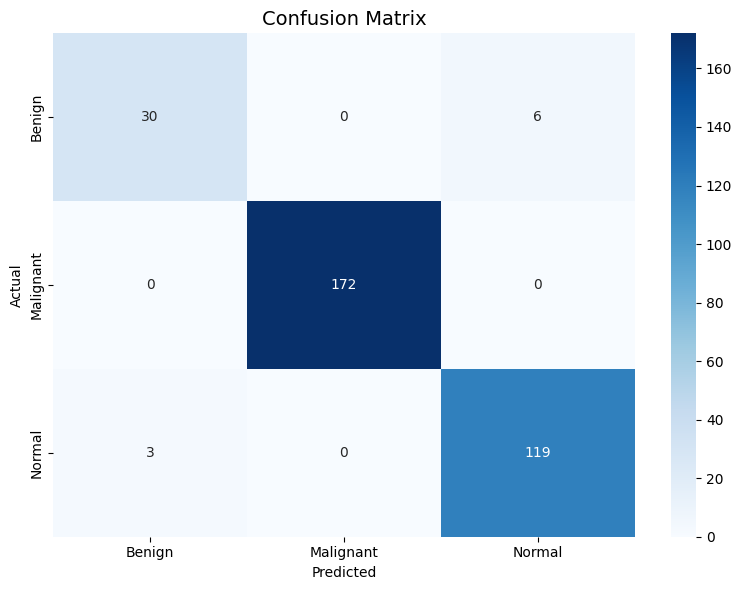


--- Performance Metrics ---
              precision    recall  f1-score   support

      Benign       0.91      0.83      0.87        36
   Malignant       1.00      1.00      1.00       172
      Normal       0.95      0.98      0.96       122

    accuracy                           0.97       330
   macro avg       0.95      0.94      0.94       330
weighted avg       0.97      0.97      0.97       330

Metric               AlexNet (Paper)      Our Model (ResNet-18)
------------------------------------------------------------
Accuracy             93.548%              97.273%


In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("\n--- Performance Metrics ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Makaledeki metriklerle karşılaştırma
from sklearn.metrics import accuracy_score
acc = accuracy_score(all_labels, all_preds) * 100
print(f"{'Metric':<20} {'AlexNet (Paper)':<20} {'Our Model (ResNet-18)'}")
print("-" * 60)
print(f"{'Accuracy':<20} {'93.548%':<20} {acc:.3f}%")

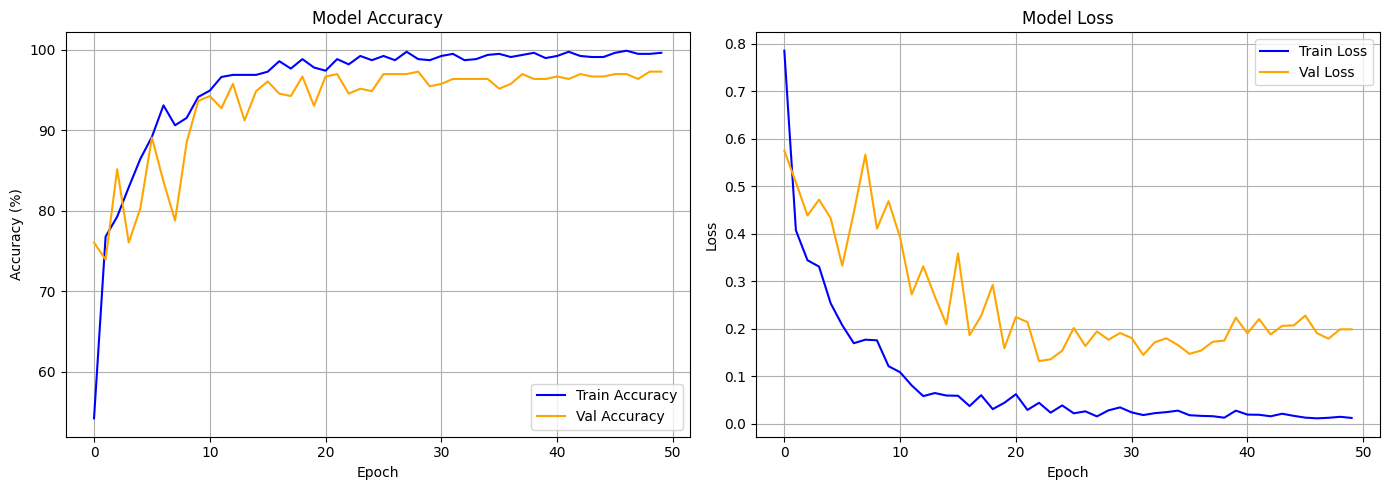

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(train_accs, label='Train Accuracy', color='blue')
ax1.plot(val_accs, label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(train_losses, label='Train Loss', color='blue')
ax2.plot(val_losses, label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

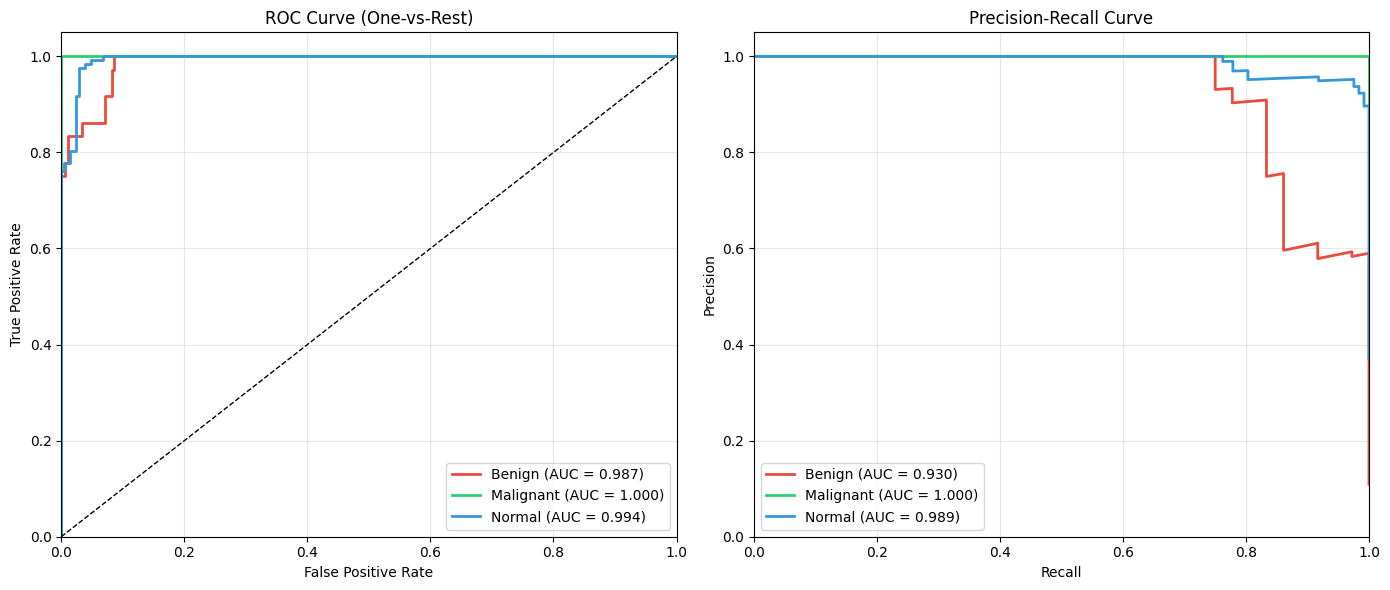


--- AUC Scores ---
Benign: ROC-AUC = 0.9874
Malignant: ROC-AUC = 1.0000
Normal: ROC-AUC = 0.9939


In [11]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Tüm sınıflar için probability scores al
model.eval()
all_probs, all_labels_list = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels_list.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels_arr = np.array(all_labels_list)

# Binarize labels (one-vs-rest)
all_labels_bin = label_binarize(all_labels_arr, classes=[0, 1, 2])

colors = ['#e74c3c', '#2ecc71', '#3498db']

# ── ROC-AUC ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (One-vs-Rest)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# ── Precision-Recall ──
for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(all_labels_bin[:, i], all_probs[:, i])
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, color=color, lw=2, label=f'{cls} (AUC = {pr_auc:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)
plt.show()

# AUC değerlerini yazdır
print("\n--- AUC Scores ---")
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    print(f"{cls}: ROC-AUC = {auc(fpr, tpr):.4f}")